In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')

week-3 under milestone-2
importing the necessary libraris and analyzing further

In [2]:
import os 
os.listdir
df=pd.read_csv('../Data/Processed/flights_2018_processed.csv')
df.head()

,FL_DATE,OP_CARRIER,ORIGIN,DEST,CRS_DEP_TIME,DEP_TIME,DEP_DELAY,ARR_TIME,ARR_DELAY,CANCELLED,DISTANCE,CRS_ARR_TIME,TAXI_IN,TAXI_OUT,FL_DATE,MONTH,DAY_OF_WEEK,DAY_NAME,DEP_HOUR,ROUTE
0,2018-01-01,UA,EWR,DEN,1517,1512.0,-5.0,1722.0,-23.0,0,1605.0,1745,10.0,15.0,2018-01-01,1,0,Monday,15,EWR-DEN
1,2018-01-01,UA,LAS,SFO,1115,1107.0,-8.0,1230.0,-24.0,0,414.0,1254,7.0,11.0,2018-01-01,1,0,Monday,11,LAS-SFO
2,2018-01-01,UA,SNA,DEN,1335,1330.0,-5.0,1636.0,-13.0,0,846.0,1649,5.0,15.0,2018-01-01,1,0,Monday,13,SNA-DEN
3,2018-01-01,UA,RSW,ORD,1546,1552.0,6.0,1754.0,-2.0,0,1120.0,1756,6.0,19.0,2018-01-01,1,0,Monday,15,RSW-ORD
4,2018-01-01,UA,ORD,ALB,630,650.0,20.0,936.0,14.0,0,723.0,922,10.0,13.0,2018-01-01,1,0,Monday,6,ORD-ALB


In [3]:
df.columns=df.columns.str.strip()

In [4]:
df = df.loc[:, ~df.columns.duplicated()]

In [5]:
df.columns

Index(['FL_DATE', 'OP_CARRIER', 'ORIGIN', 'DEST', 'CRS_DEP_TIME', 'DEP_TIME',
       'DEP_DELAY', 'ARR_TIME', 'ARR_DELAY', 'CANCELLED', 'DISTANCE',
       'CRS_ARR_TIME', 'TAXI_IN', 'TAXI_OUT', 'MONTH', 'DAY_OF_WEEK',
       'DAY_NAME', 'DEP_HOUR', 'ROUTE'],
      dtype='object')

!!!— UNIVARIATE ANALYSIS
   -We analyze one variable at a time.

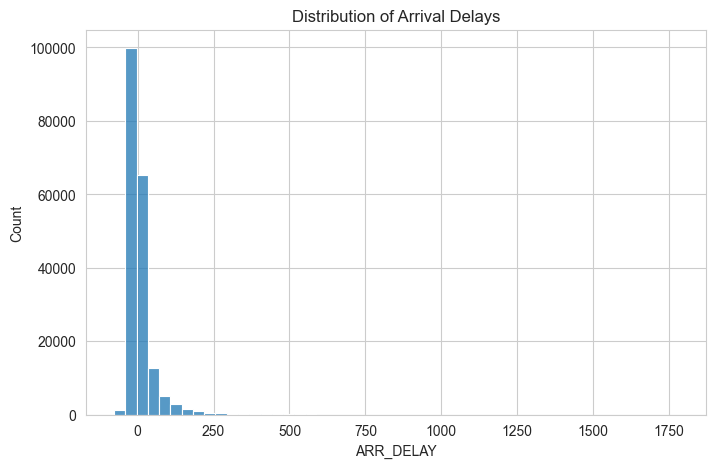

In [6]:
# Arrival Delay Distribution (Histogram)
plt.figure(figsize=(8,5))
sns.histplot(df['ARR_DELAY'], bins=50)
plt.title("Distribution of Arrival Delays")
plt.show()

Interpretation:

The distribution of arrival delays is right-skewed, meaning most flights experience small delays.

A large number of flights have delays close to 0–50 minutes.

A few flights show very high delays, creating extreme outliers.

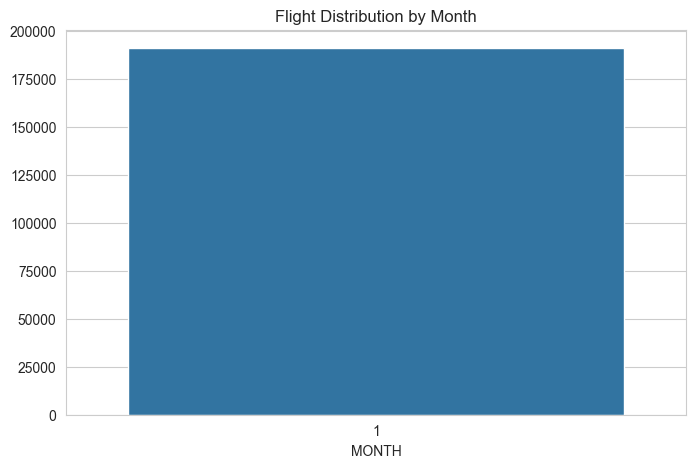

In [7]:
# Flights by Month (Bar Chart)
monthly = df['MONTH'].value_counts().sort_index()

plt.figure(figsize=(8,5))
sns.barplot(x=monthly.index, y=monthly.values)
plt.title("Flight Distribution by Month")
plt.show()

In [23]:
df['MONTH'].unique()

array([1])

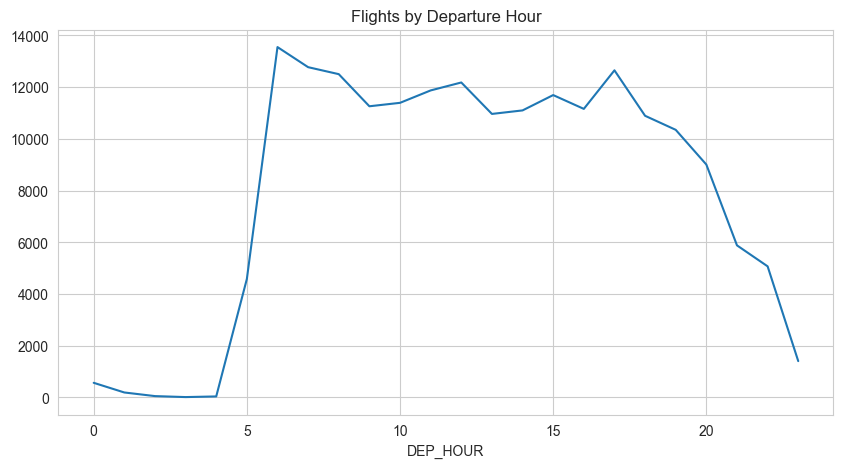

In [8]:
# Flights by Departure Hour (Line Plot)
hour_dist = df['DEP_HOUR'].value_counts().sort_index()

plt.figure(figsize=(10,5))
sns.lineplot(x=hour_dist.index, y=hour_dist.values)
plt.title("Flights by Departure Hour")
plt.show()

the distribution of flights by departure hour shows that very flights operate during late night and early morning hours
12am-4am actively incresed around 5am b/w 7am and 9am high morning traffic decresing late evening

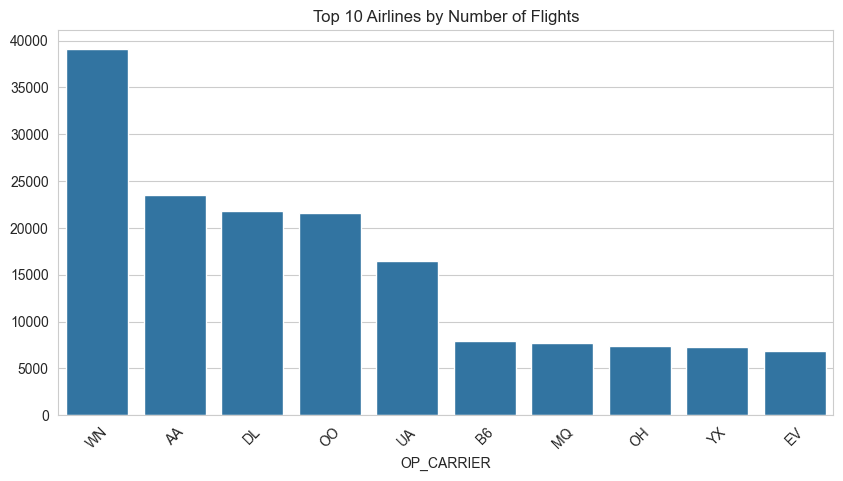

In [9]:
# Top Airlines (Bar Chart)/
top_airlines = df['OP_CARRIER'].value_counts().head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top_airlines.index, y=top_airlines.values)
plt.title("Top 10 Airlines by Number of Flights")
plt.xticks(rotation=45)
plt.show()

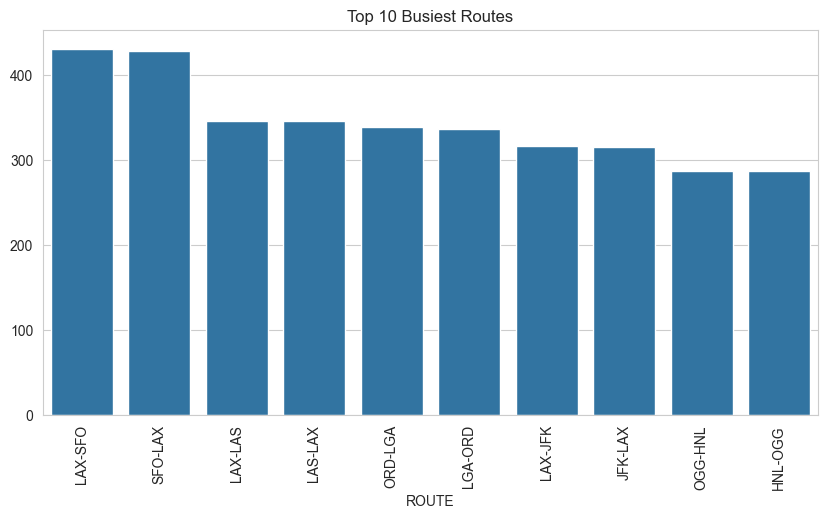

In [10]:
# Top Routes (Bar Chart)
top_routes = df['ROUTE'].value_counts().head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top_routes.index, y=top_routes.values)
plt.xticks(rotation=90)
plt.title("Top 10 Busiest Routes")
plt.show()

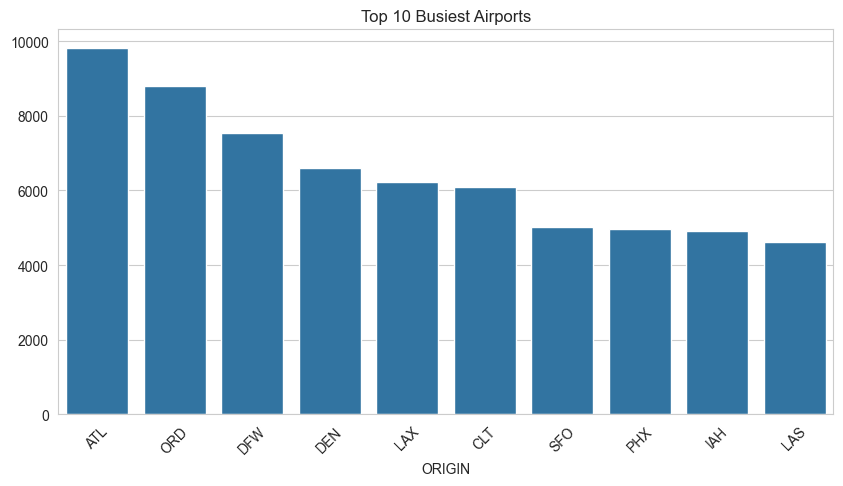

In [11]:
# Flight Distribution by Airport (Origin)
top_airports = df['ORIGIN'].value_counts().head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top_airports.index, y=top_airports.values)
plt.xticks(rotation=45)
plt.title("Top 10 Busiest Airports")
plt.show()

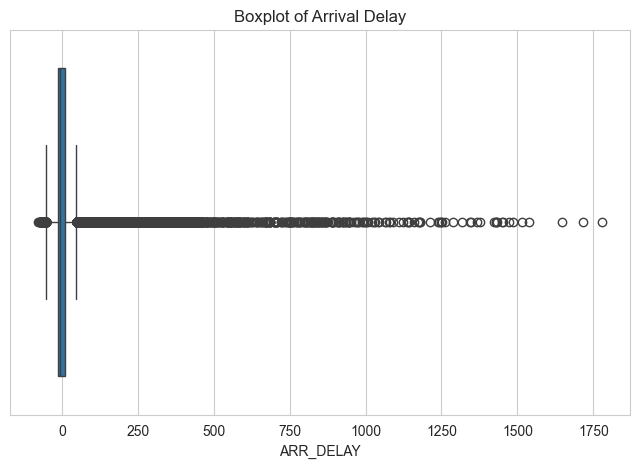

In [12]:
# Boxplot for Delay (Outlier Understanding)
plt.figure(figsize=(8,5))
sns.boxplot(x=df['ARR_DELAY'])
plt.title("Boxplot of Arrival Delay")
plt.show()

shows most arrival delay near lower values majarity of flights have minimal delayextrenm outliers on higher side

!!!— BIVARIATE ANALYSIS
   -Now compare two variables

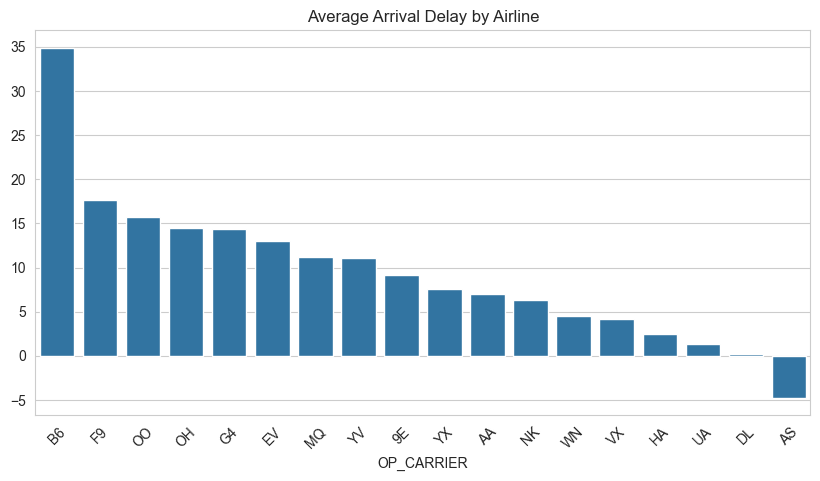

In [13]:
# Airline vs Average Delay
airline_delay = df.groupby('OP_CARRIER')['ARR_DELAY'].mean().sort_values(ascending=False)

plt.figure(figsize=(10,5))
sns.barplot(x=airline_delay.index, y=airline_delay.values)
plt.title("Average Arrival Delay by Airline")
plt.xticks(rotation=45)
plt.show()

In [1]:
# # Month vs Average Delay
# month_delay = df.groupby('MONTH')['ARR_DELAY'].mean()

# plt.figure(figsize=(8,5))
# sns.lineplot(x=month_delay.index, y=month_delay.values)
# plt.title("Average Arrival Delay by Month")
# plt.show()

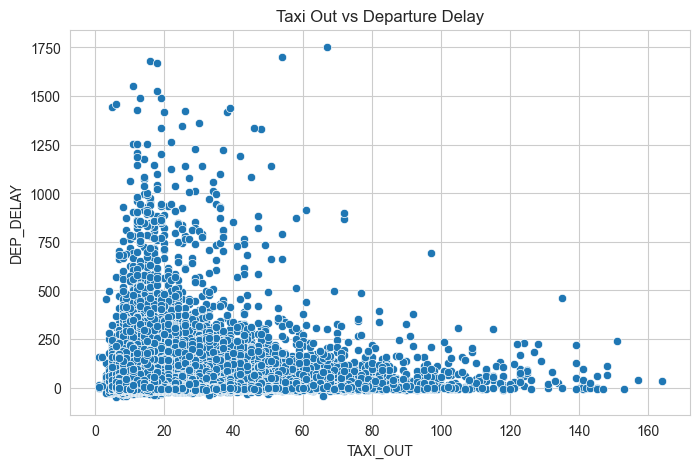

In [15]:
# Taxi-Out vs Departure Delay (Scatter)
plt.figure(figsize=(8,5))
sns.scatterplot(x='TAXI_OUT', y='DEP_DELAY', data=df)
plt.title("Taxi Out vs Departure Delay")
plt.show()

In [ ]:
shows a weak relationship b/w taxi-out time and depature delay 
some have long taxi-out time experience

# Milestone 2 – Week 4: Delay Analysis (Seasonal & Operational)


In [16]:
# Create Season Column This converts MONTH → SEASON.
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Fall'

df['SEASON'] = df['MONTH'].apply(get_season)

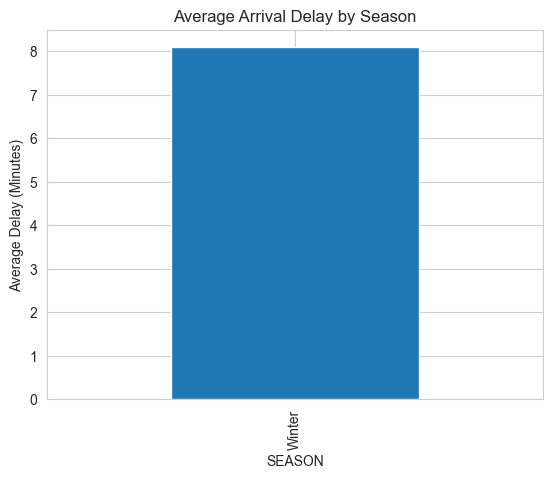

In [17]:
# Average Delay by Season (Main Plot)
season_delay = df.groupby('SEASON')['ARR_DELAY'].mean()

plt.figure()
season_delay.plot(kind='bar')
plt.title("Average Arrival Delay by Season")
plt.ylabel("Average Delay (Minutes)")
plt.show()

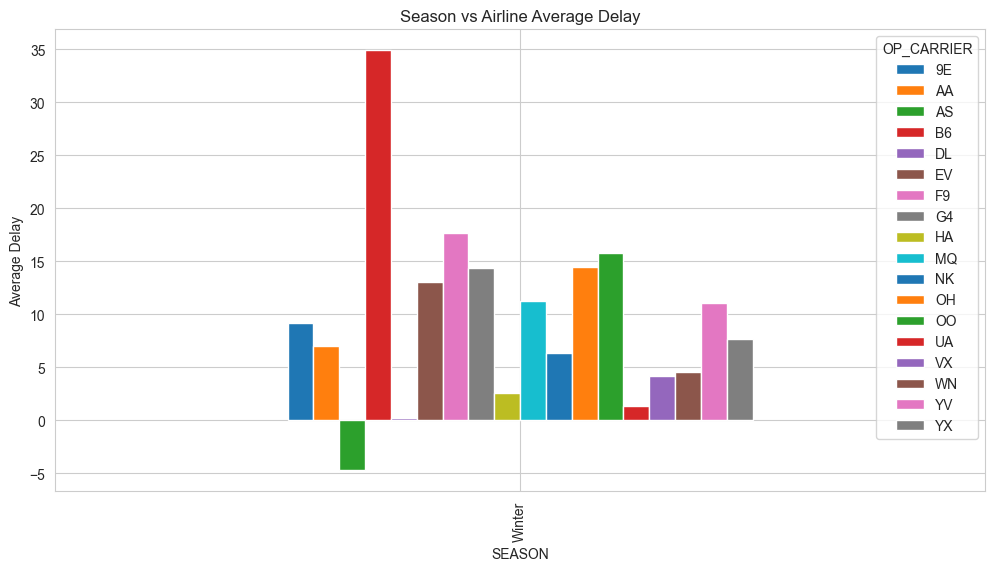

In [18]:
# Season vs Airline Delay (Important Bivariate)
season_airline = df.groupby(['SEASON','OP_CARRIER'])['ARR_DELAY'].mean().unstack()

season_airline.plot(kind='bar', figsize=(12,6))
plt.title("Season vs Airline Average Delay")
plt.ylabel("Average Delay")
plt.show()

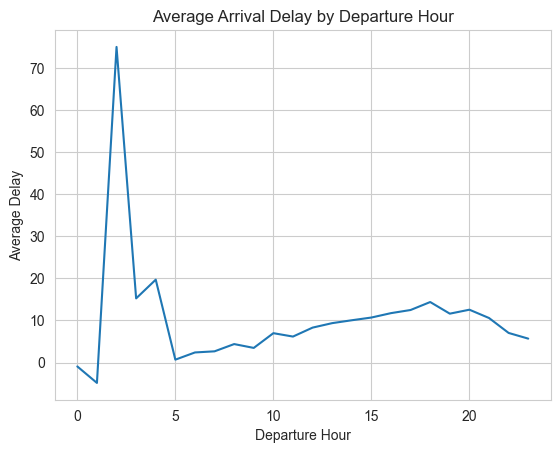

In [19]:
# Delay by Time of Day
hour_delay = df.groupby('DEP_HOUR')['ARR_DELAY'].mean()

plt.figure()
hour_delay.plot()
plt.title("Average Arrival Delay by Departure Hour")
plt.xlabel("Departure Hour")
plt.ylabel("Average Delay")
plt.show()

In [2]:
# # Rolling Average (Temporal Intelligence Concept)
# df['FL_DATE'] = pd.to_datetime(df['FL_DATE'])

# daily_delay = df.groupby('FL_DATE')['ARR_DELAY'].mean()

# rolling_delay = daily_delay.rolling(window=30).mean()

# plt.figure(figsize=(10,5))
# rolling_delay.plot()
# plt.title("30-Day Rolling Average of Arrival Delay")
# plt.ylabel("Average Delay")
# plt.show()

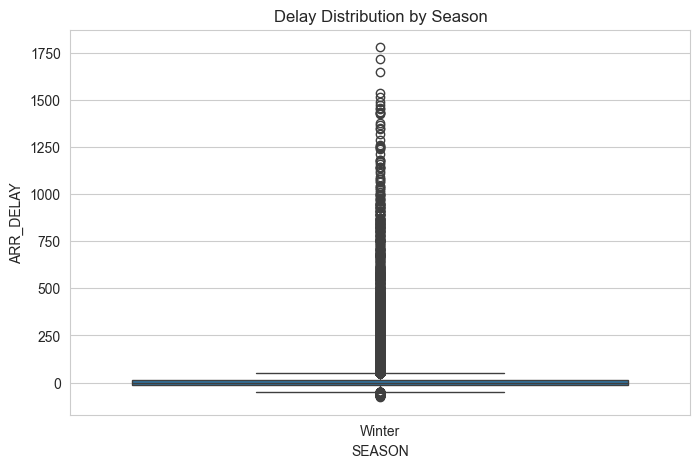

In [21]:
# Seasonal Delay Comparison Using Boxplot
plt.figure(figsize=(8,5))
sns.boxplot(x='SEASON', y='ARR_DELAY', data=df)
plt.title("Delay Distribution by Season")
plt.show()